# BPS5231 Topic 16A — Exploratory Data Analysis

**Case:** CityLearn Challenge 2022 Phase All, `Building_5`  
**Scope:** one residential building, 8,760 hourly steps. This notebook describes the supplied load, PV, tariff and carbon-intensity signals. It does not simulate a battery controller.

The source files do not contain a complete calendar timestamp. All joins use the row order specified by the dataset schema, and plots retain source month/hour labels.

In [1]:
import io
import json
import os
import runpy
from contextlib import redirect_stdout
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/bps5231-matplotlib")

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

def locate_project(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "05_exploratory_data_analysis.py").exists() and (candidate / "data" / "processed" / "building_5_hourly_inputs.csv").exists():
            return candidate
    raise FileNotFoundError("Cannot locate the topic16a_interim project directory")

ROOT = locate_project(Path.cwd())
print(f"Project root: {ROOT}")

Project root: /Users/jh_skye/Documents/Codex/2026-09-24/2025-lectures/work/BPS5231/topic16a_interim


## 1. Input audit

In [2]:
data = pd.read_csv(ROOT / "data" / "processed" / "building_5_hourly_inputs.csv")
required = [
    "time_step", "month_source", "hour_source_1_to_24", "day_type_source",
    "load_kwh_step", "pv_generation_kwh_step",
    "electricity_price_currency_per_kwh", "carbon_intensity_kgco2_per_kwh",
]
assert len(data) == 8760
assert data[required].isna().sum().sum() == 0
assert data["time_step"].tolist() == list(range(8760))
assert (data[["load_kwh_step", "pv_generation_kwh_step", "electricity_price_currency_per_kwh", "carbon_intensity_kgco2_per_kwh"]] >= 0).all().all()

audit = json.loads((ROOT / "data" / "processed" / "data_audit.json").read_text())
pd.DataFrame({
    "check": ["Rows", "Missing core values", "Annual load", "Annual PV", "Potential surplus hours", "Price–carbon Pearson r"],
    "value": [
        len(data), 0,
        audit["derived_screening"]["annual_load_kwh"],
        audit["derived_screening"]["annual_pv_kwh"],
        audit["derived_screening"]["potential_pv_surplus_hours"],
        audit["derived_screening"]["price_carbon_pearson_r"],
    ],
})

,check,value
0,Rows,8760.000000
1,Missing core values,0.000000
2,Annual load,8807.643180
3,Annual PV,6067.641222
4,Potential surplus hours,2586.000000
5,Price–carbon Pearson r,0.313013


## 2. Reproduce EDA tables and figures

In [3]:
captured = io.StringIO()
with redirect_stdout(captured):
    runpy.run_path(str(ROOT / "05_exploratory_data_analysis.py"), run_name="__main__")
print("EDA script completed and regenerated results/eda plus figures/eda.")

EDA script completed and regenerated results/eda plus figures/eda.


## 3. Key descriptive results

In [4]:
summary = json.loads((ROOT / "results" / "eda" / "eda_summary.json").read_text())
key_results = pd.DataFrame([
    ("Annual building load", summary["annual_load_kwh"], "kWh"),
    ("Annual PV generation", summary["annual_pv_generation_kwh"], "kWh"),
    ("Pre-battery grid import", summary["potential_grid_import_before_battery_kwh"], "kWh"),
    ("Potential PV surplus", summary["potential_pv_surplus_before_battery_kwh"], "kWh"),
    ("Pre-battery peak import", summary["peak_import_before_battery_kw"], "kW"),
    ("Price–carbon Pearson r", summary["price_carbon_pearson_r"], "dimensionless"),
], columns=["Metric", "Value", "Unit"])
key_results.style.format({"Value": "{:.4f}"})

,Metric,Value,Unit
0,Annual building load,8807.6432,kWh
1,Annual PV generation,6067.6412,kWh
2,Pre-battery grid import,4957.9506,kWh
3,Potential PV surplus,2217.9486,kWh
4,Pre-battery peak import,4.9388,kW
5,Price–carbon Pearson r,0.3130,dimensionless


## 4. EDA figures

01_selected_week_load_pv_net.png


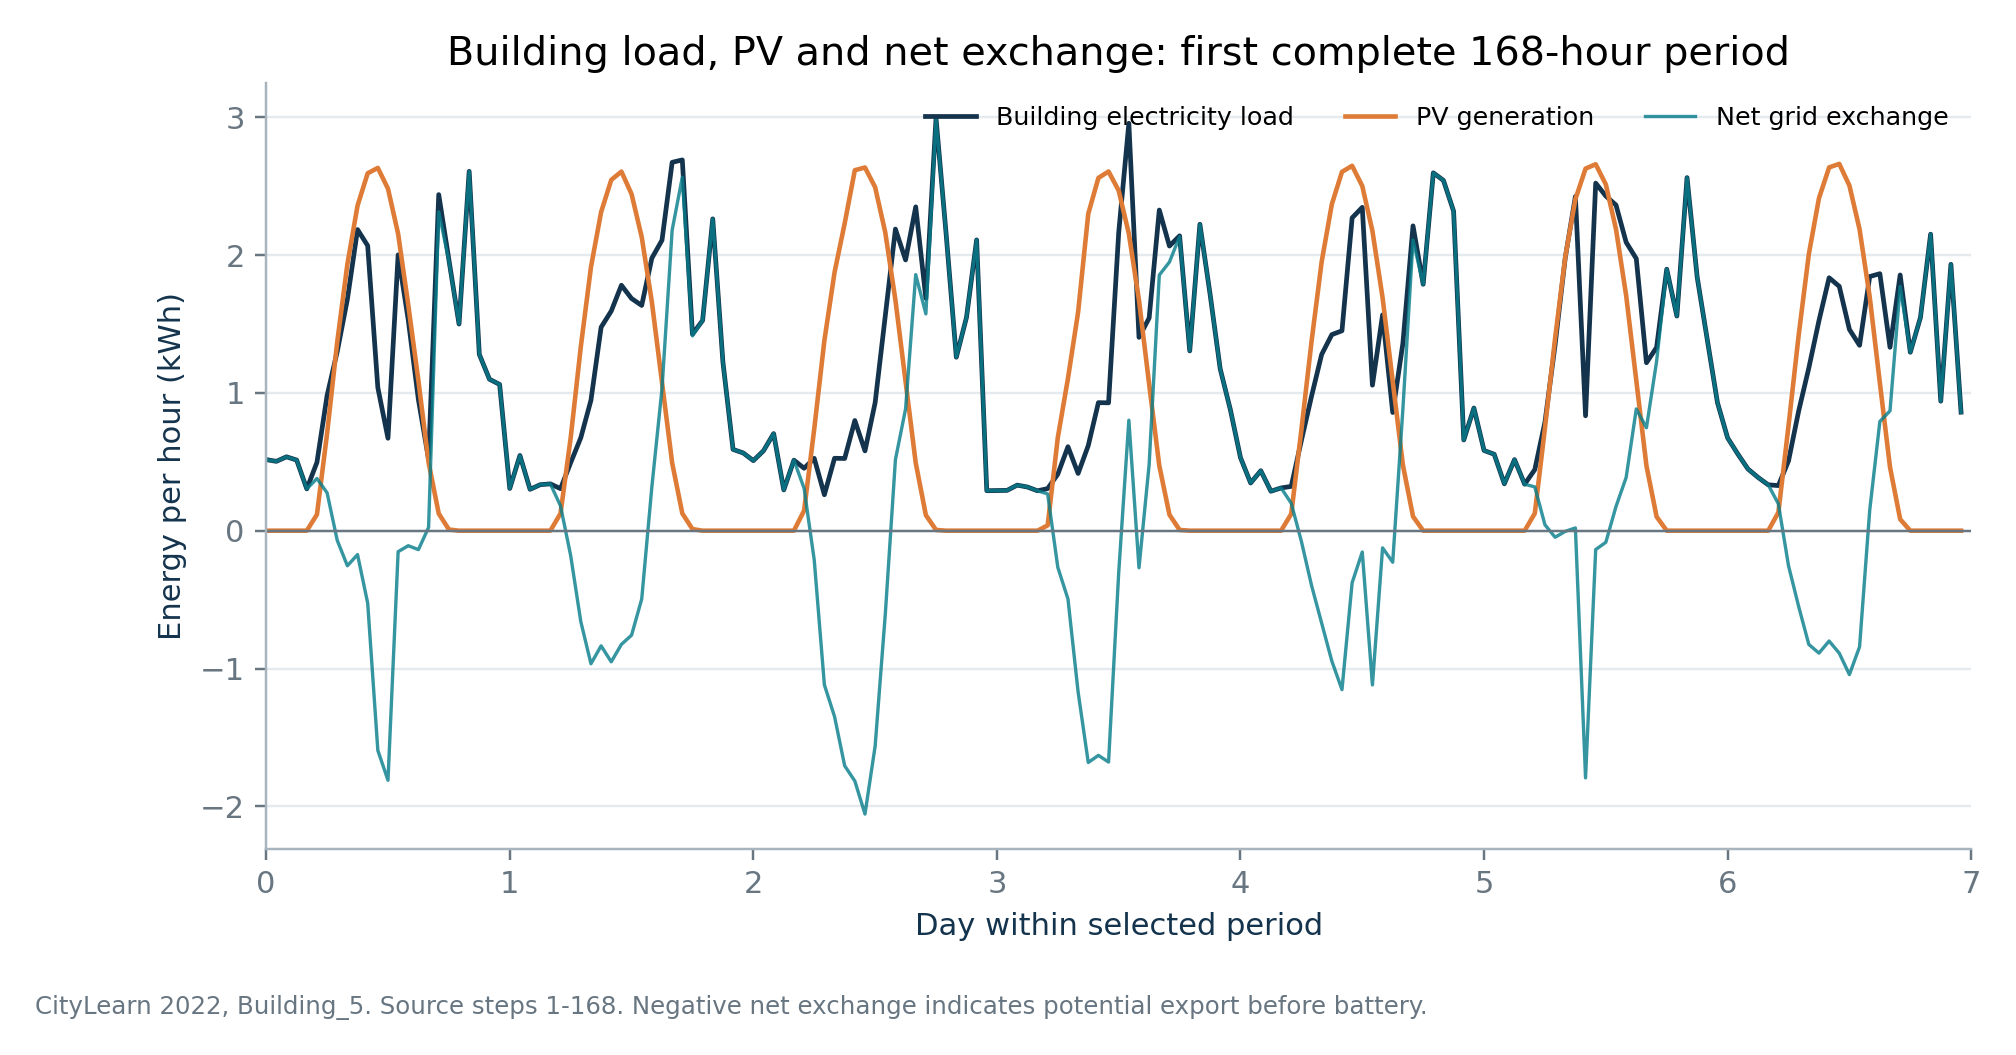

02_diurnal_load_pv.png


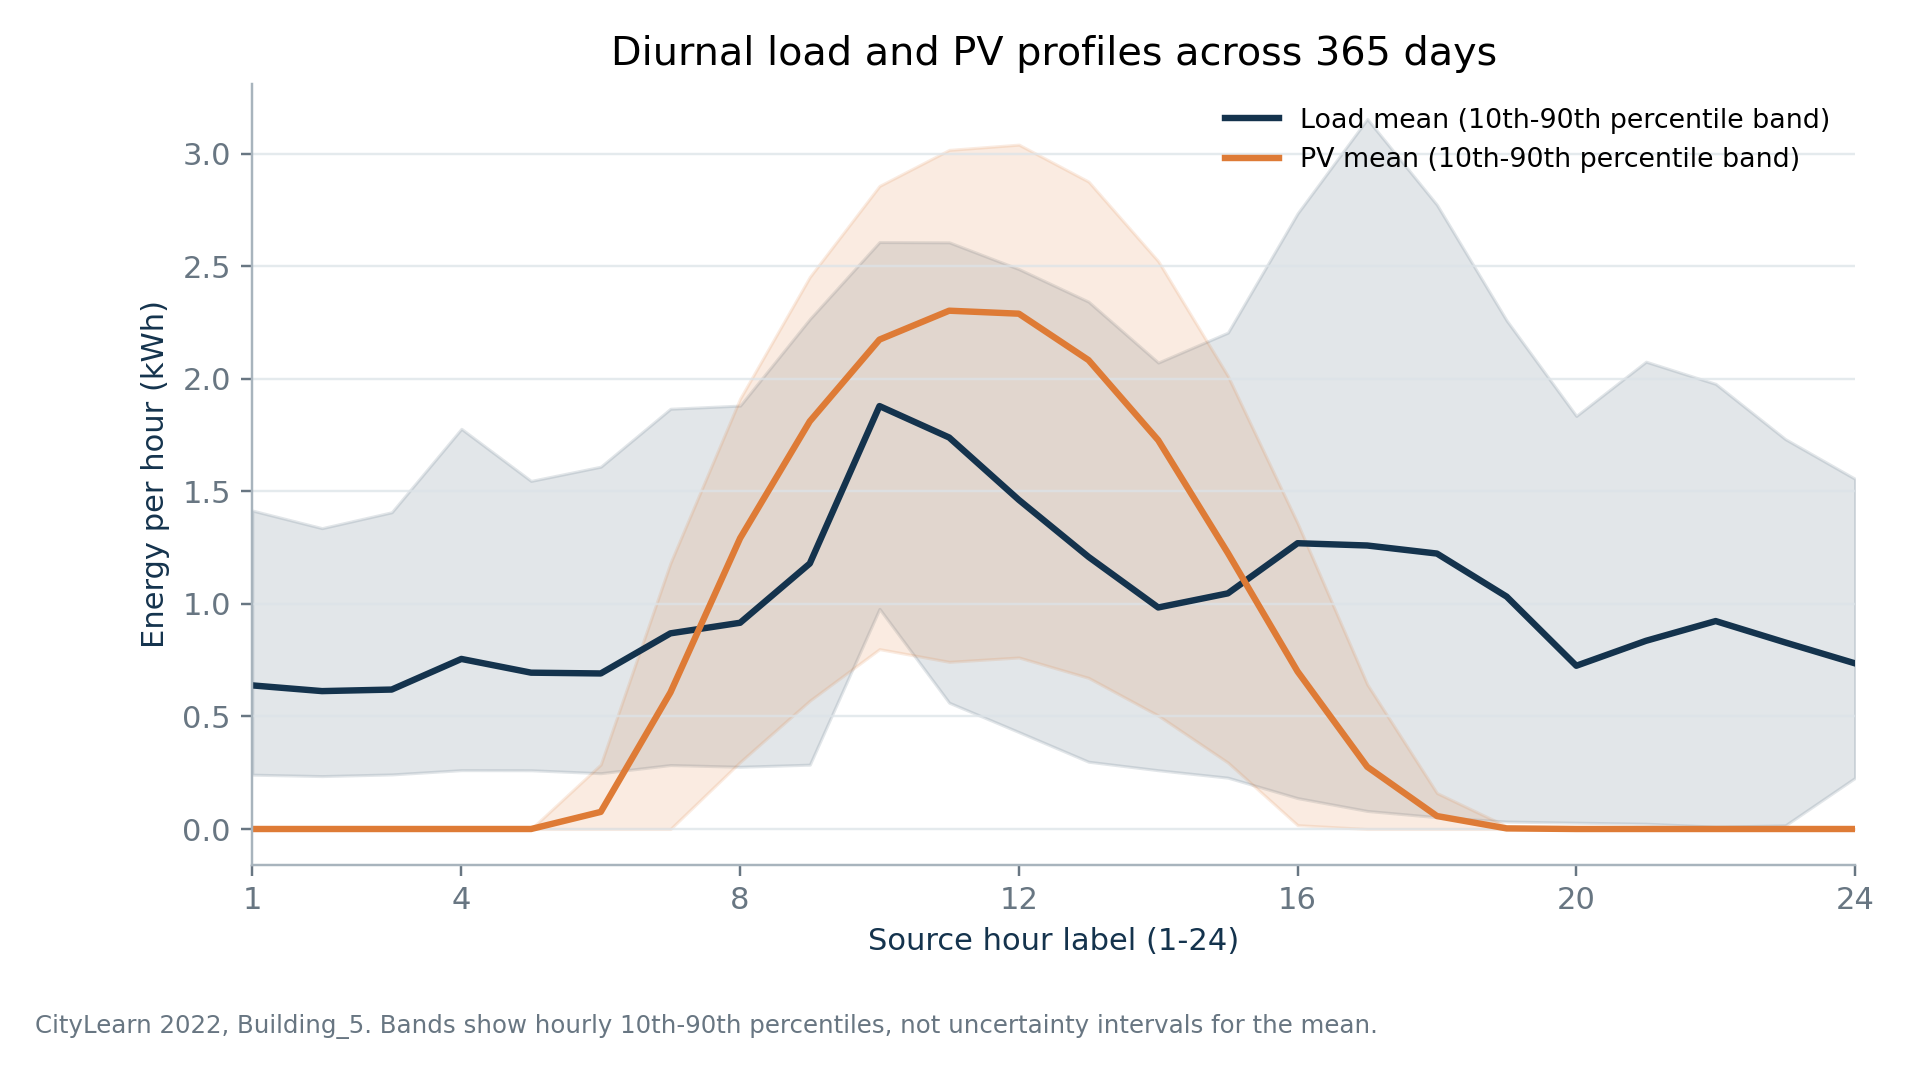

03_monthly_energy_surplus.png


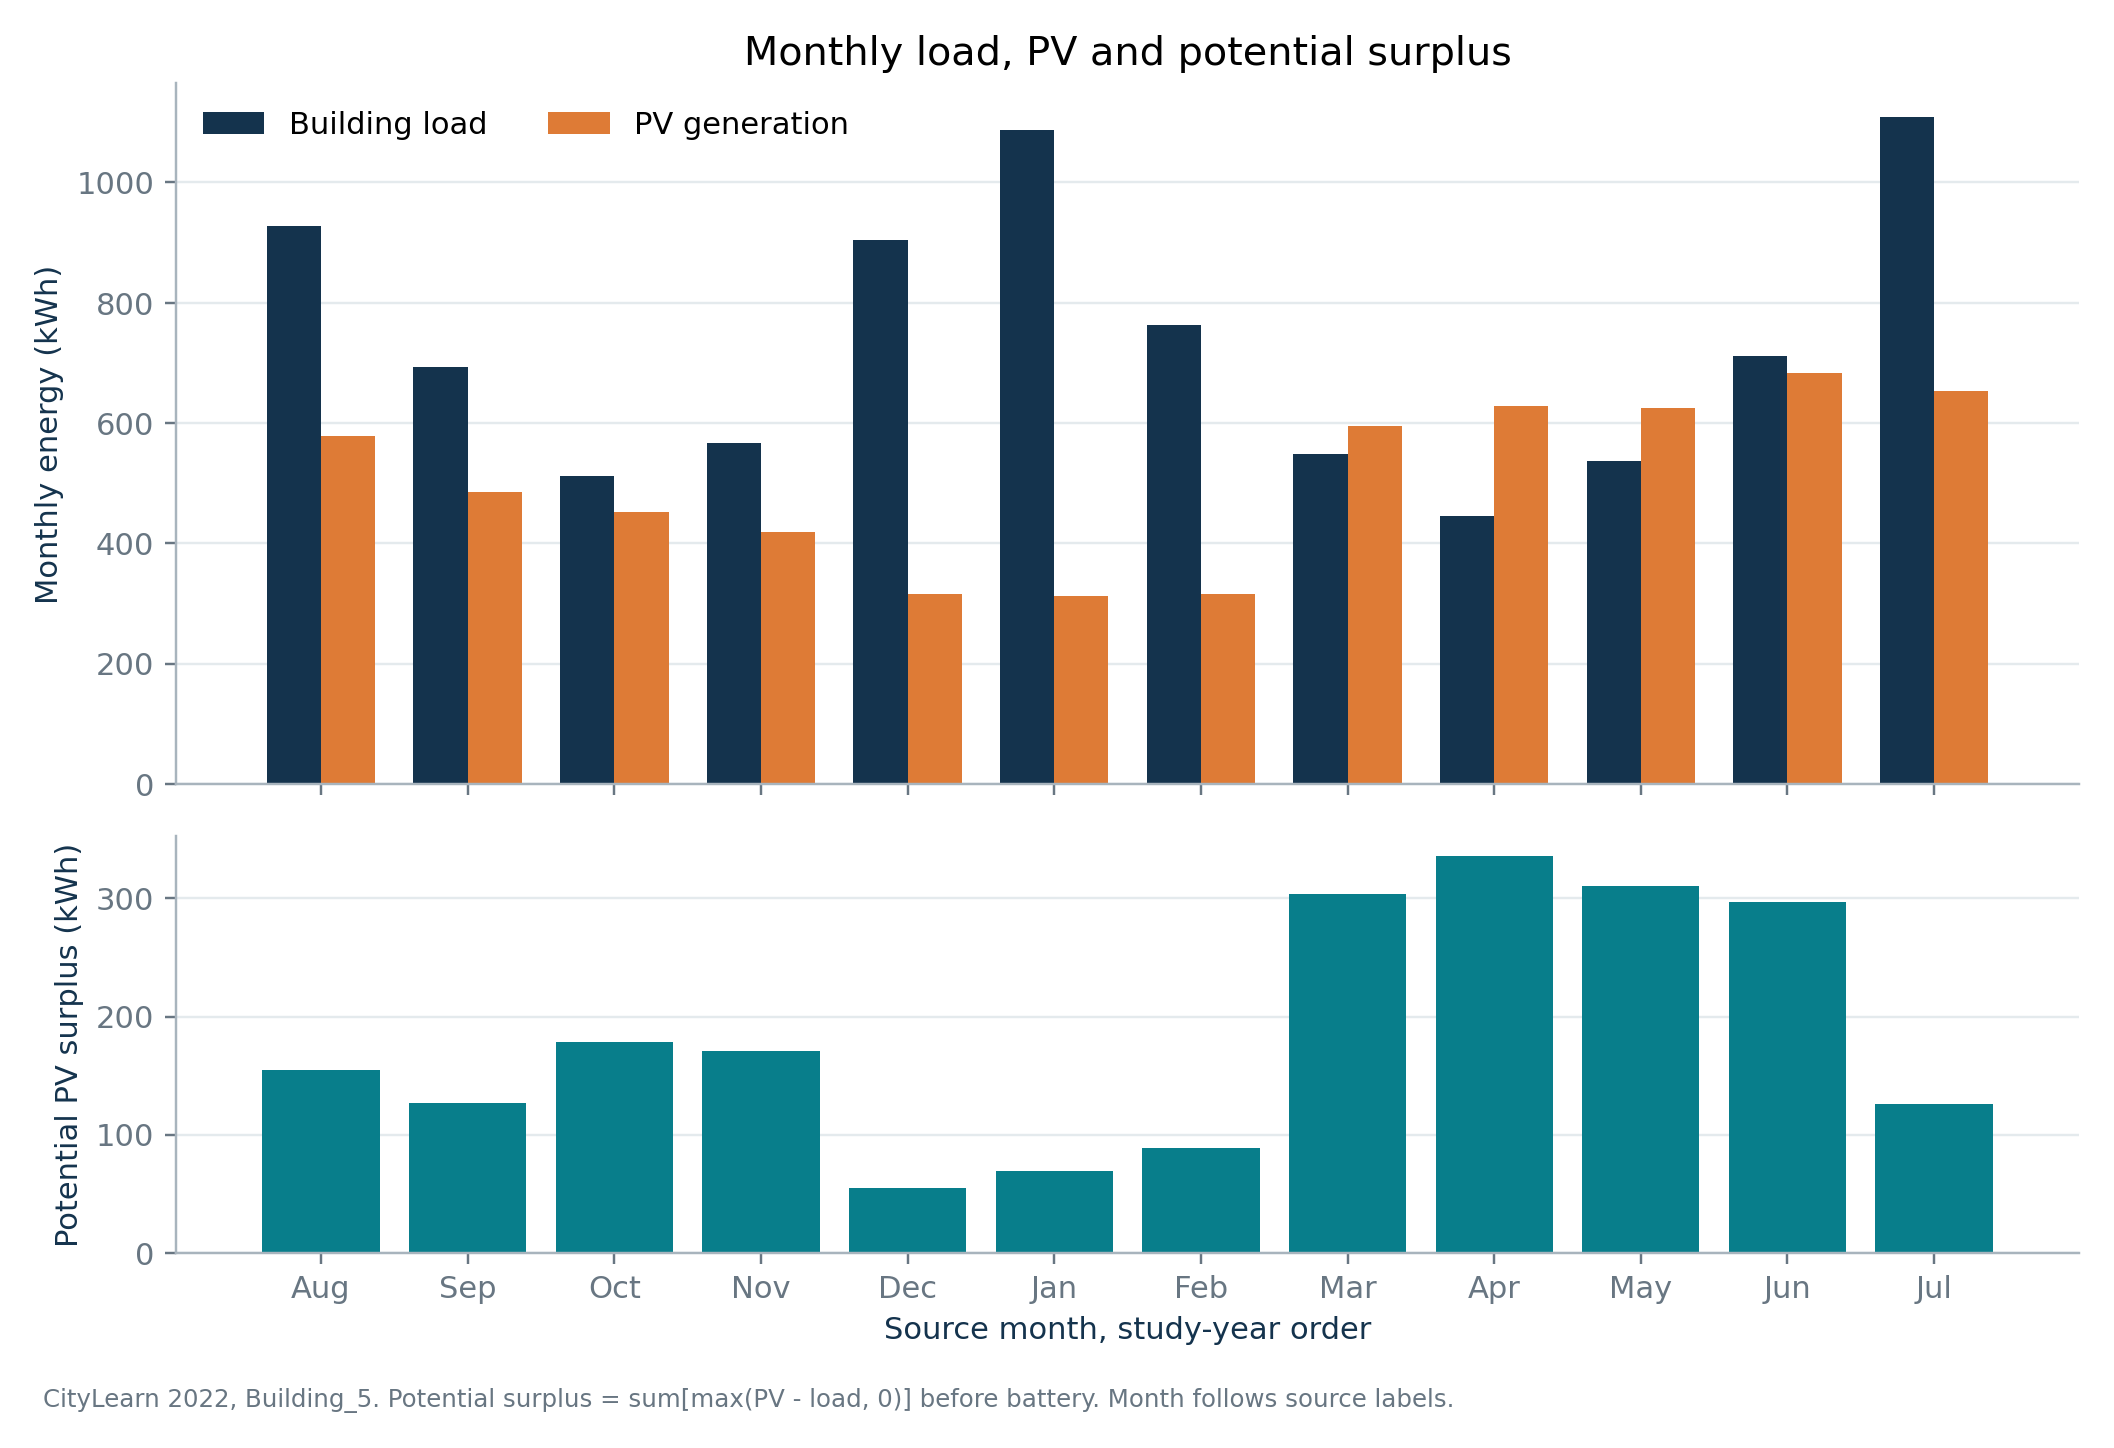

04_price_carbon_selected_week.png


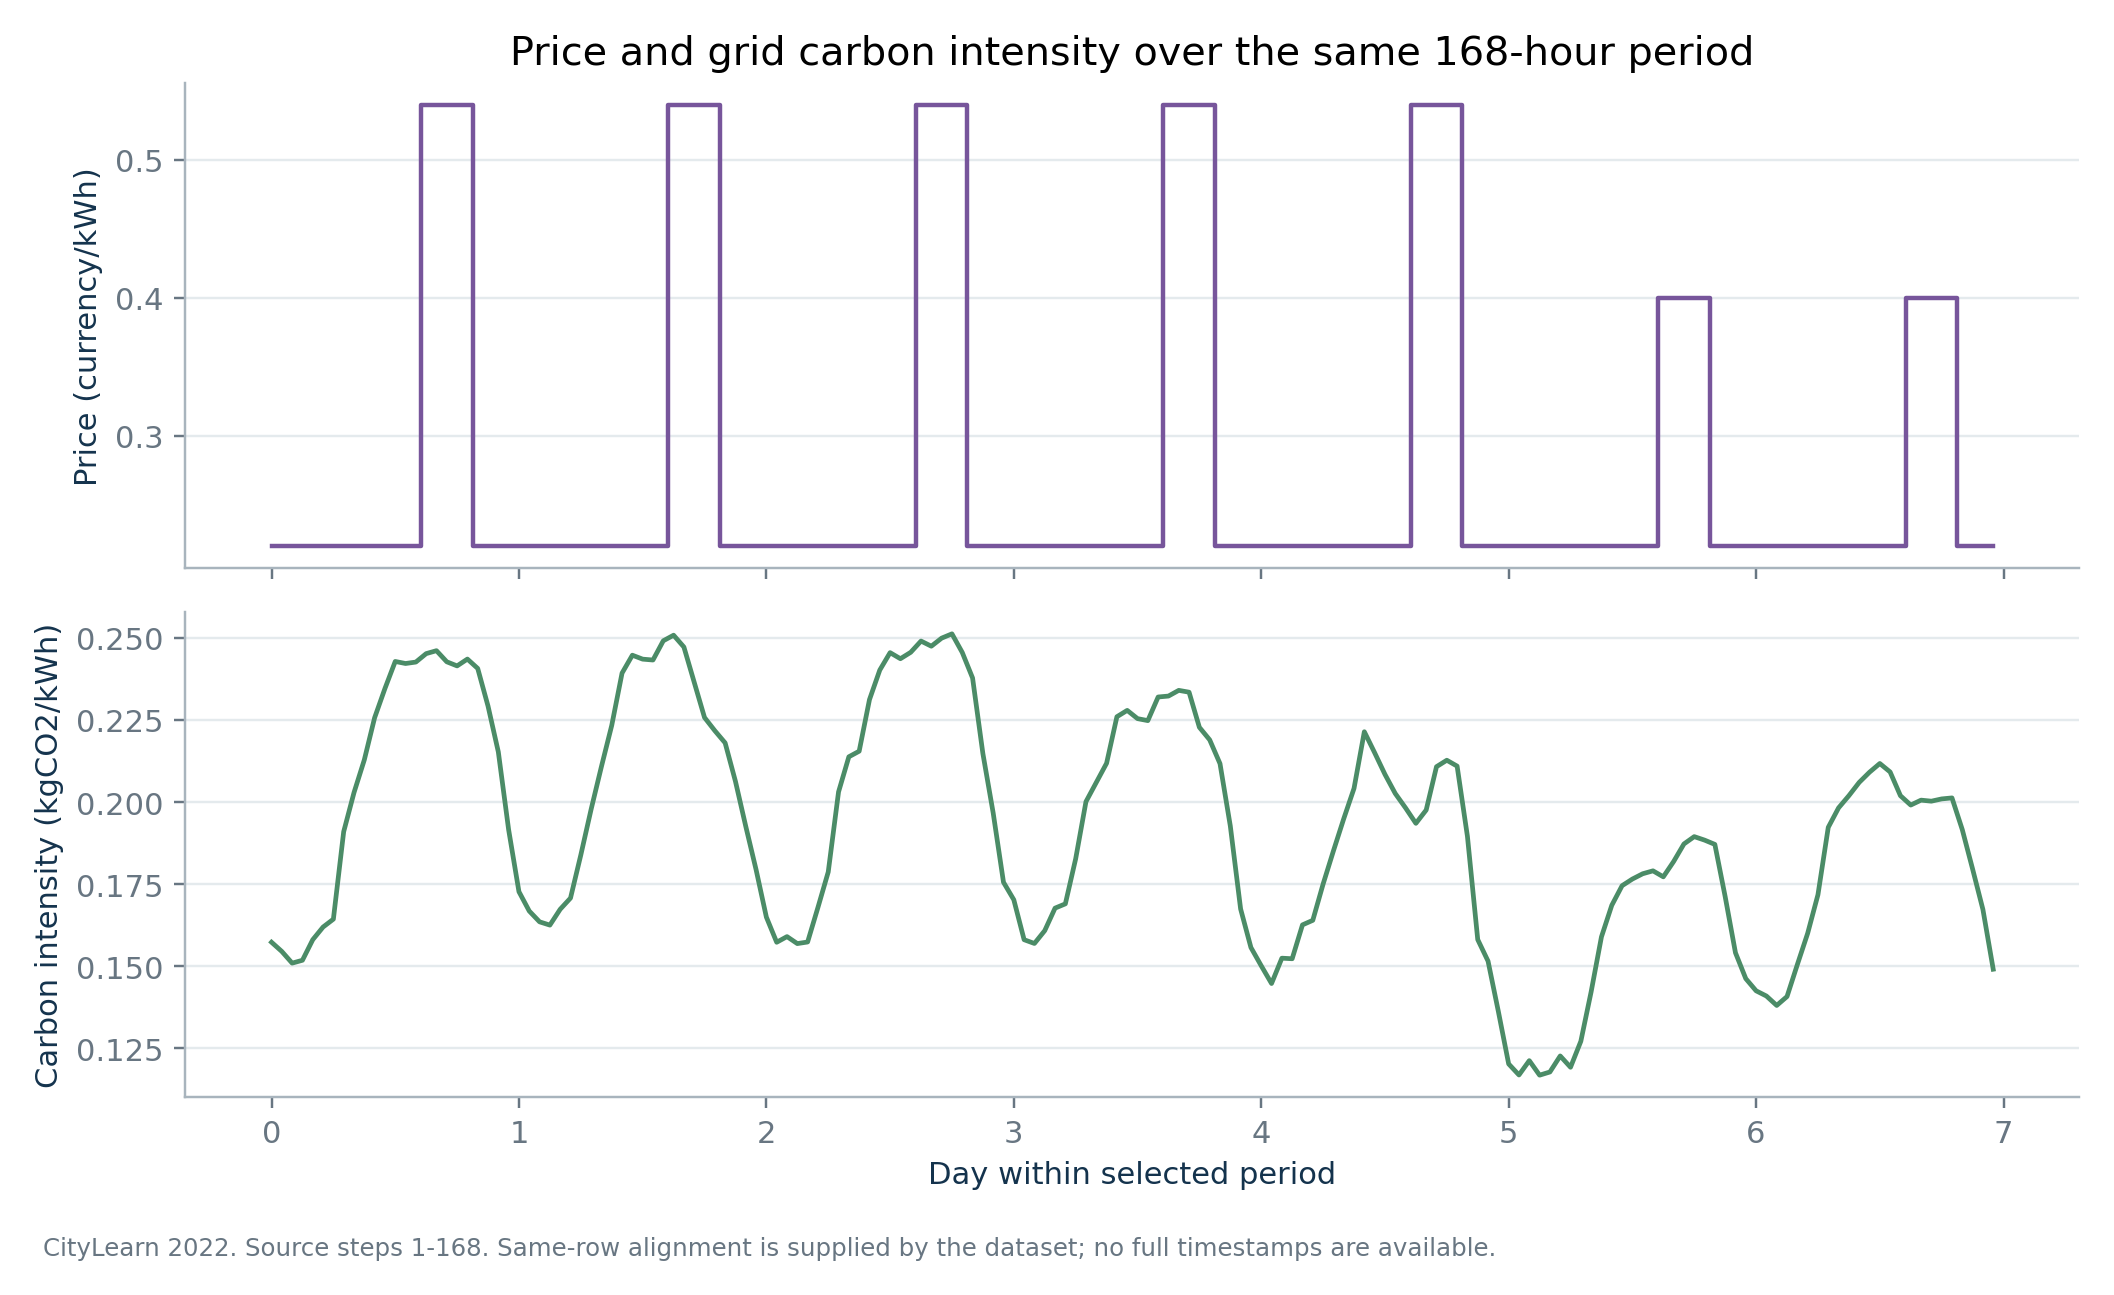

05_price_carbon_by_tariff.png


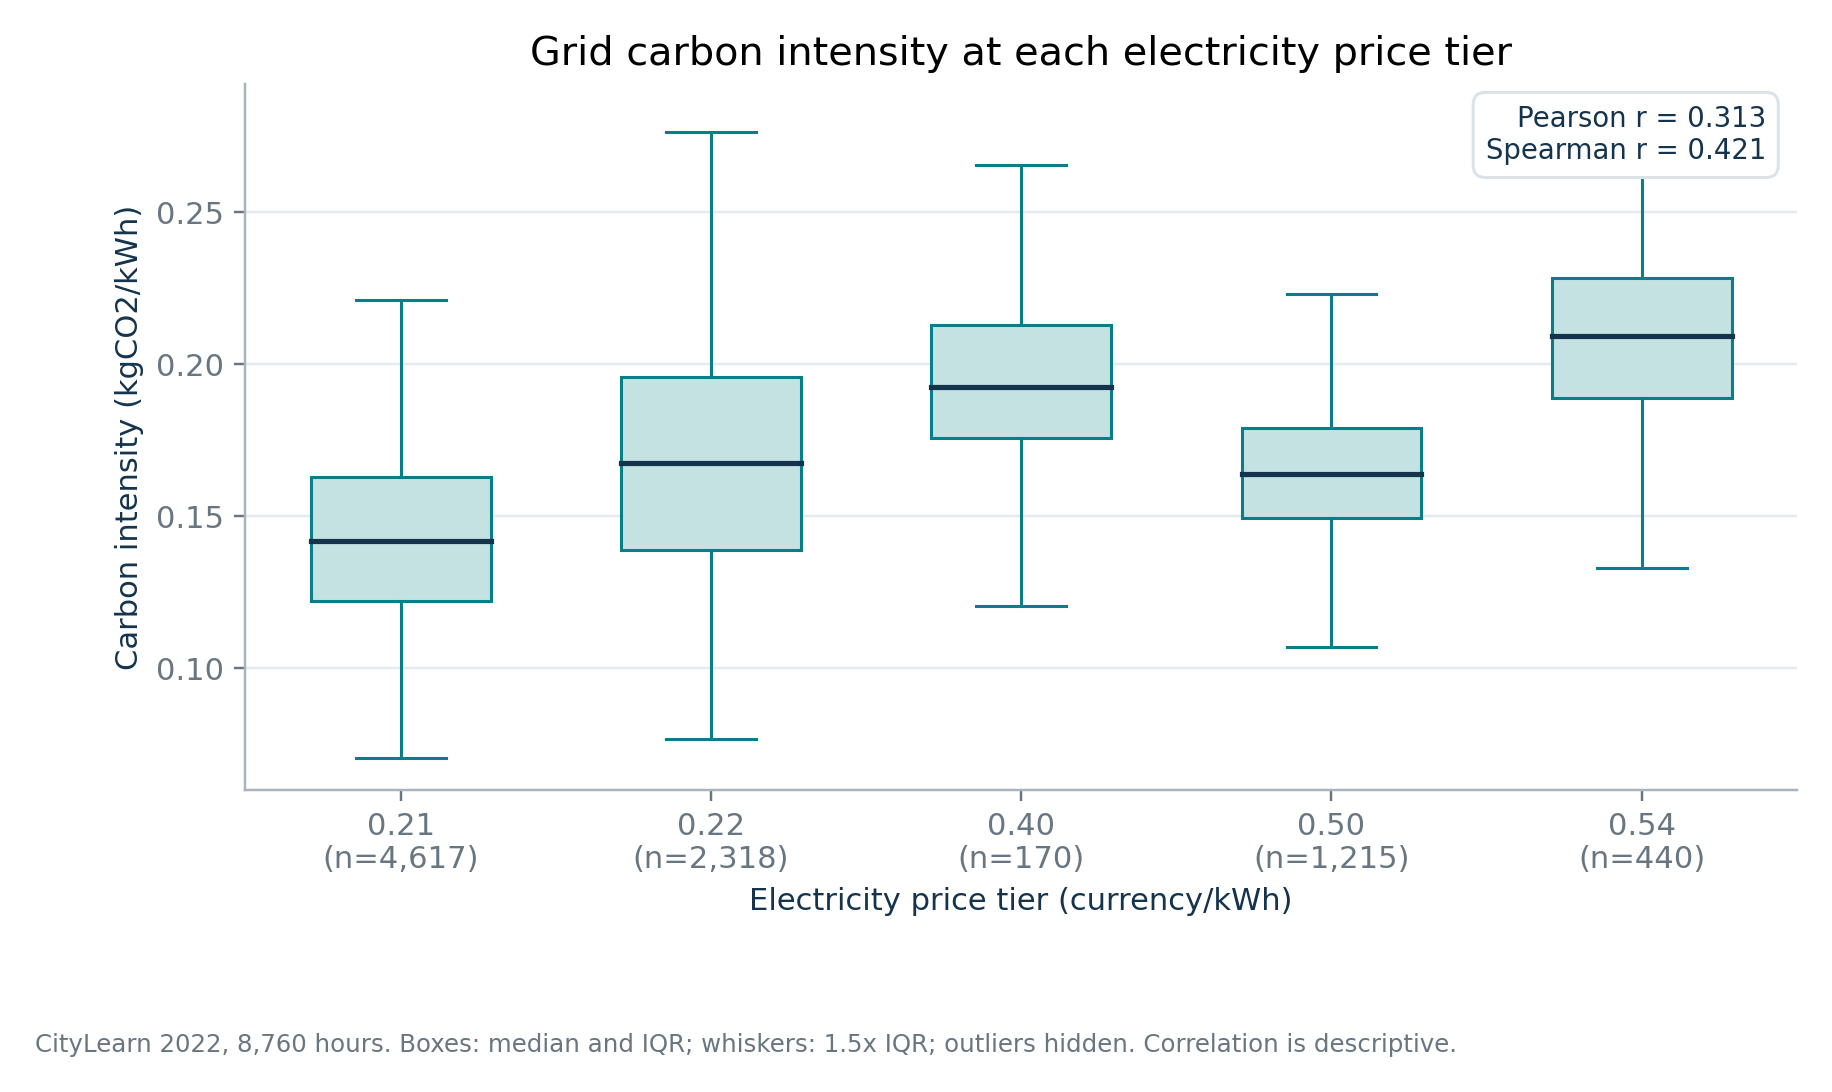

06_pv_surplus_opportunity.png


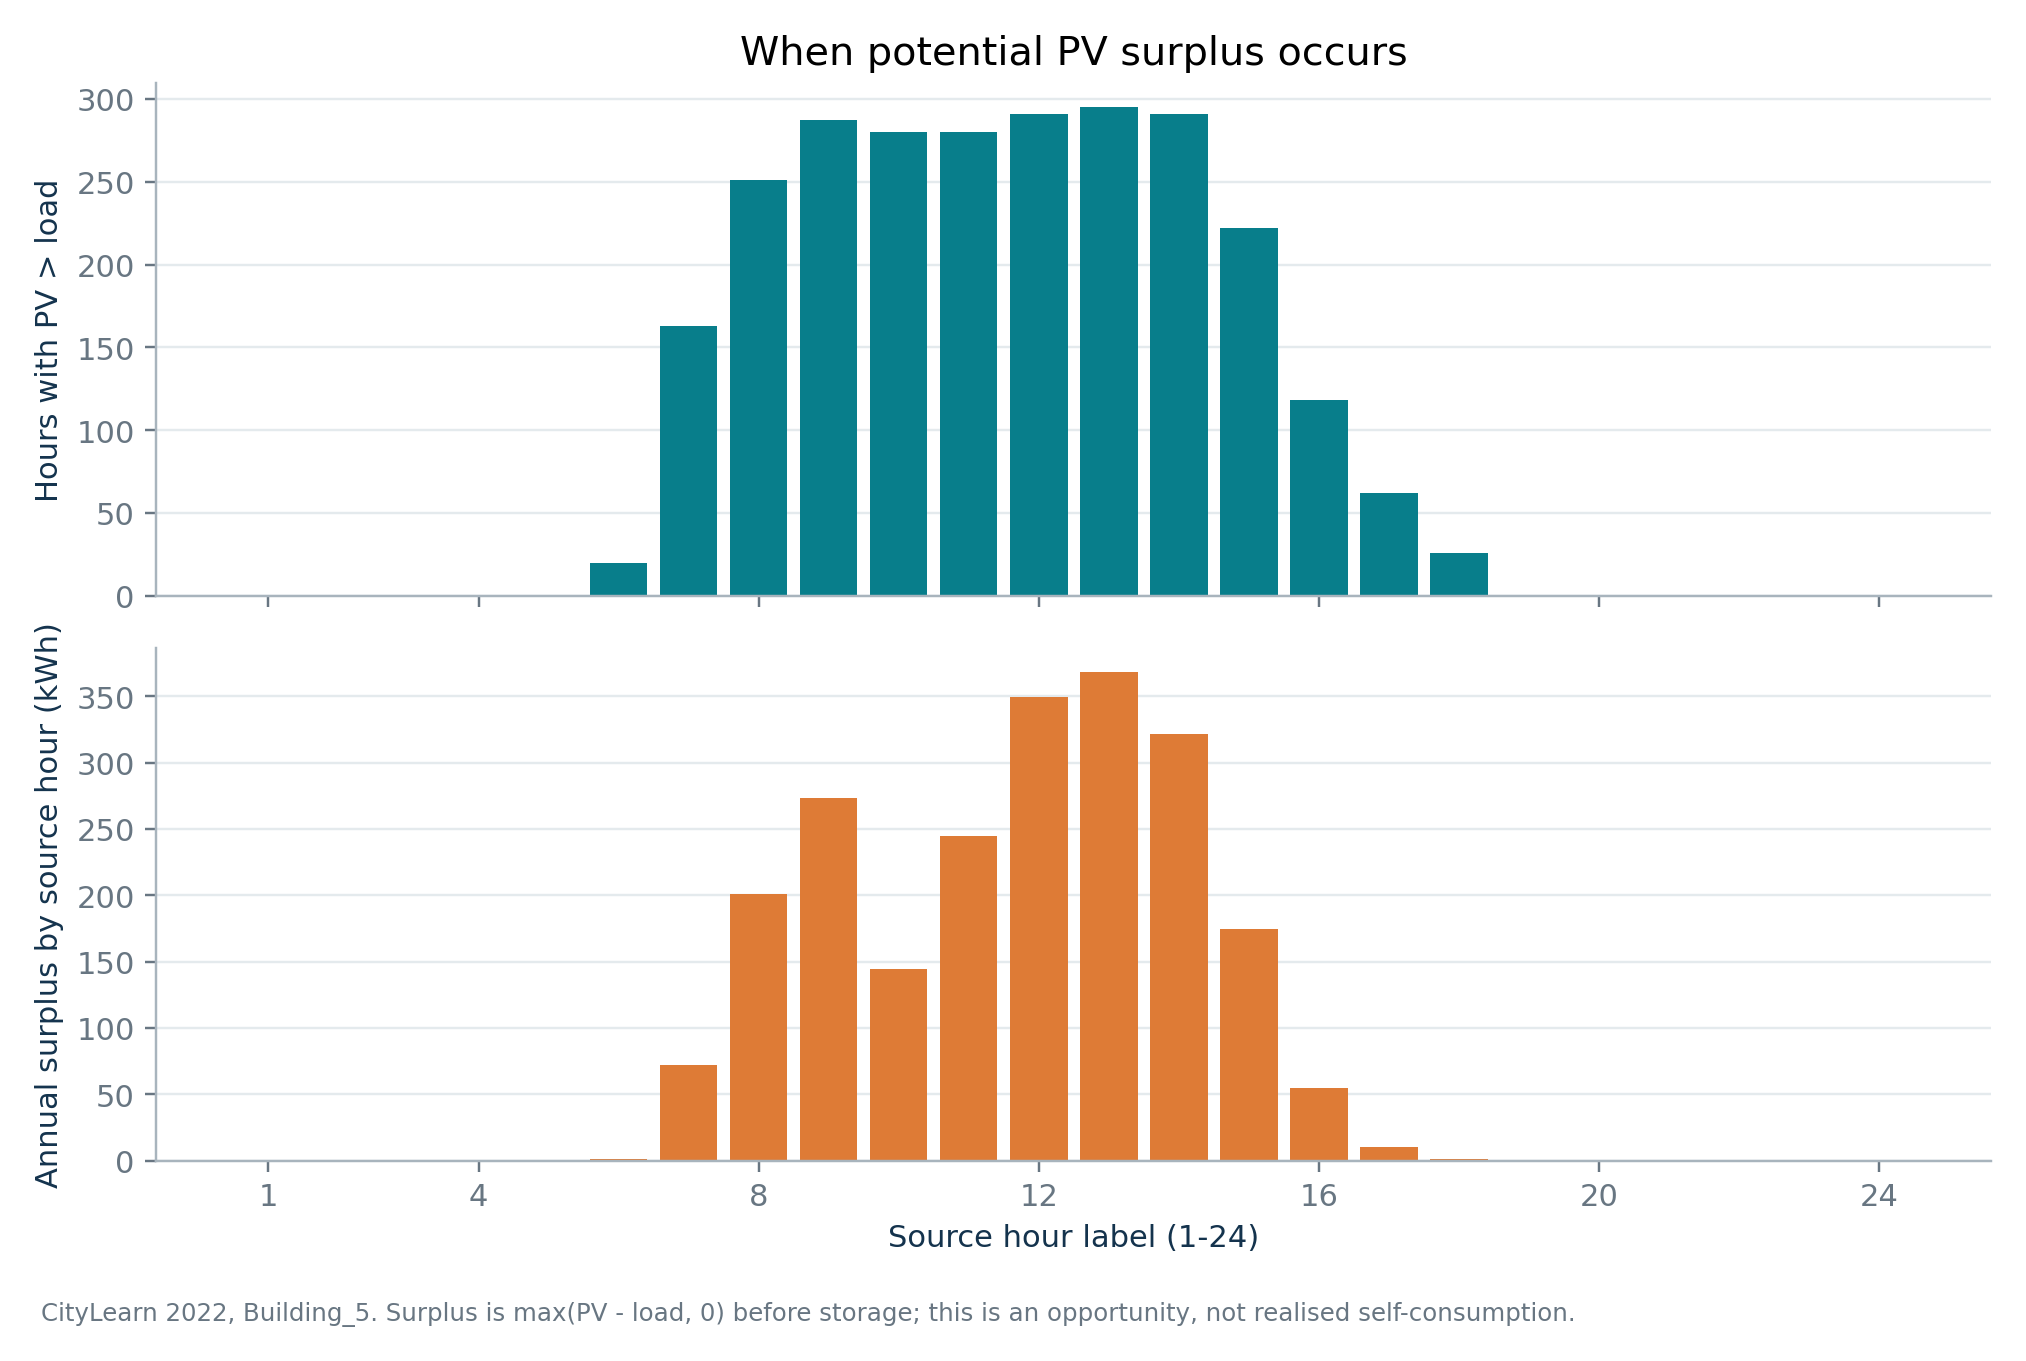

07_import_peaks_before_battery.png


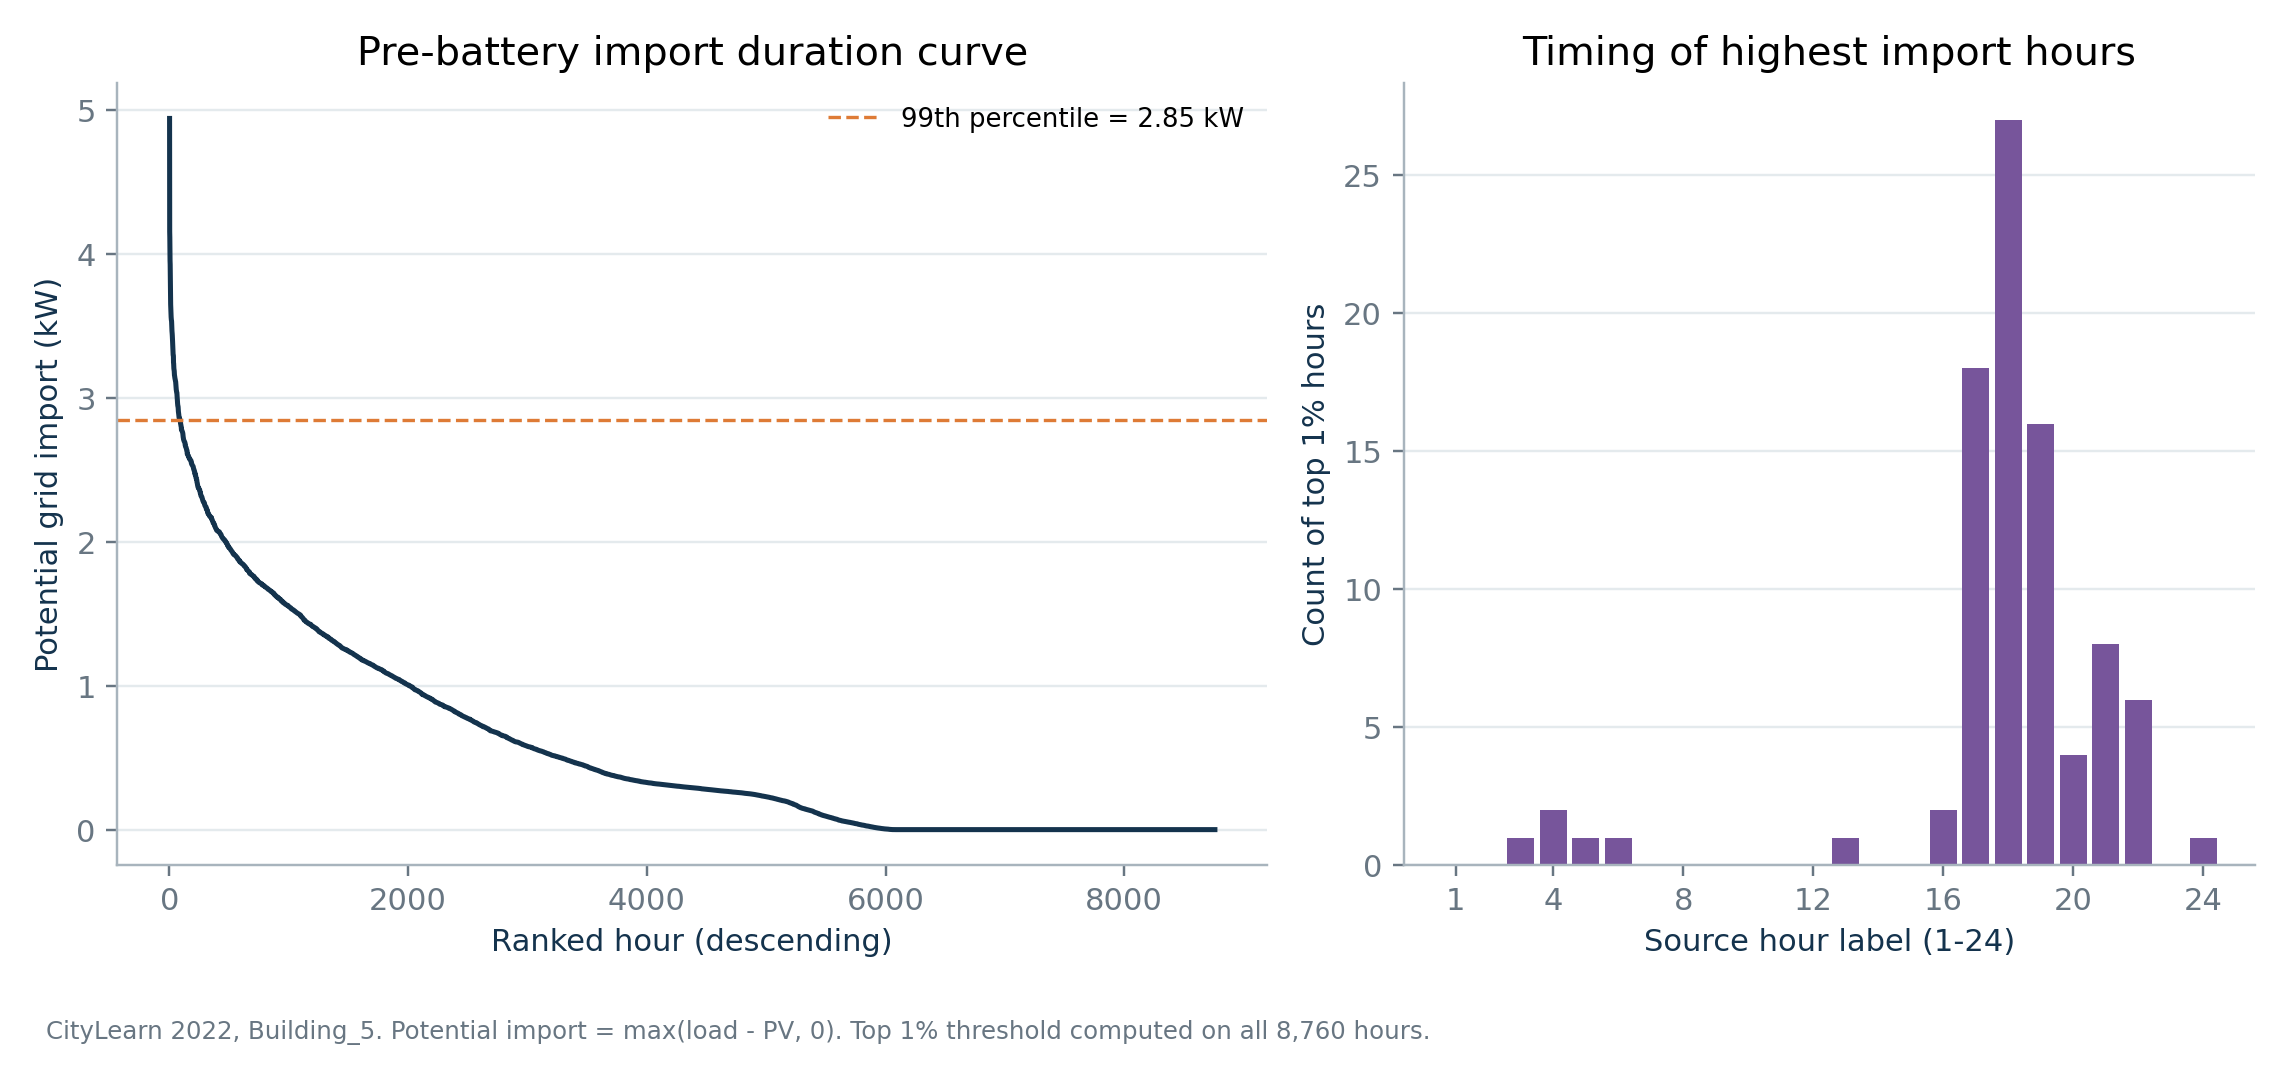

In [5]:
figure_files = [
    "01_selected_week_load_pv_net.png",
    "02_diurnal_load_pv.png",
    "03_monthly_energy_surplus.png",
    "04_price_carbon_selected_week.png",
    "05_price_carbon_by_tariff.png",
    "06_pv_surplus_opportunity.png",
    "07_import_peaks_before_battery.png",
]
for name in figure_files:
    print(name)
    display(Image(filename=str(ROOT / "figures" / "eda" / name), width=900))

## 5. Interpretation and limits

- Annual PV generation is smaller than annual load, but 2,586 hours have contemporaneous PV surplus. Storage can therefore shift some energy within the year.
- Price and carbon intensity are only moderately correlated (`r = 0.313`). This supports evaluating price and carbon control separately, but correlation alone does not prove a control trade-off.
- The pre-battery duration curve identifies when peak reduction matters. A controller must preserve SOC for those hours rather than discharging at every earlier deficit.
- The analysis is descriptive. It does not establish causality, cross-building generalisation or performance for an office building.